# Introduction
We will predict library visitors in Australian cities using AutoGluon. We will set up the environment, explore the data, build models, add covariates, and interpret feature importance.

In the end, we'll see how these techniques help us make accurate and explainable forecasts.

# Setup: Libraries and Data

We mount Google Drive, change the directory to the project folder, install the AutoGluon library, import the required libraries, and load the dataset that shows library visitors in Australian cities.


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Change directory to the project folder
%cd /content/drive/MyDrive/Python - Time Series Forecasting/Advanced Content for Time Series/Amazon AutoGluon

/content/drive/MyDrive/Python - Time Series Forecasting/Advanced Content for Time Series/Amazon AutoGluon


In [3]:
# Install the autogluon library
!pip install -q autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.7 MB/s eta 0:0

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
from autogluon.timeseries.splitter import ExpandingWindowSplitter

In [8]:
# Load the data
# This dataset shows the number of library visitors across various Australian cities
df = pd.read_csv("australia_library_data.csv")
df.head()

,datetime,location_name,no_of_people,day_of_week,temperature,rainfall,event_day
0,2024-06-01 00:00:00,Sydney,3,5,14.811082,0,1
1,2024-06-01 01:00:00,Sydney,3,5,15.545415,0,1
2,2024-06-01 02:00:00,Sydney,3,5,15.585101,0,1
3,2024-06-01 03:00:00,Sydney,3,5,14.263018,1,1
4,2024-06-01 04:00:00,Sydney,4,5,15.611136,1,1


We have our environment set up and our dataset loaded. Now we can proceed with data processing.

# Data Processing and Visualization

We rename the target column, preview the data, plot the target, and assess its basic structure.

In [9]:
# Rename the target variable for easier referencing in our modeling steps
df.rename(columns={'no_of_people': 'y'}, inplace = True)
df.head()

,datetime,location_name,y,day_of_week,temperature,rainfall,event_day
0,2024-06-01 00:00:00,Sydney,3,5,14.811082,0,1
1,2024-06-01 01:00:00,Sydney,3,5,15.545415,0,1
2,2024-06-01 02:00:00,Sydney,3,5,15.585101,0,1
3,2024-06-01 03:00:00,Sydney,3,5,14.263018,1,1
4,2024-06-01 04:00:00,Sydney,4,5,15.611136,1,1


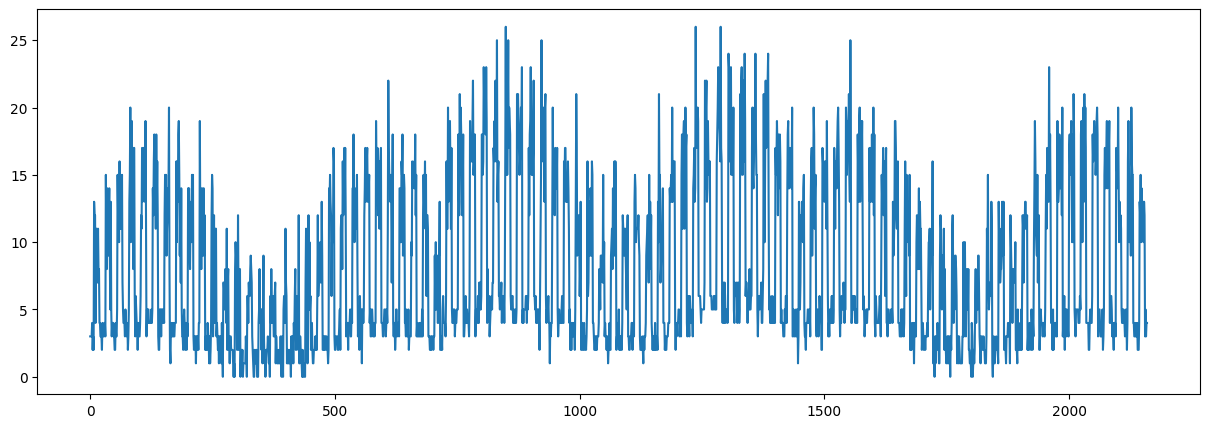

In [10]:
# Visualize the target variable over time
df.y.plot(figsize= ( 15,5))
plt.show()

In [11]:
# Show information about the DataFrame and check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       2160 non-null   object 
 1   location_name  2160 non-null   object 
 2   y              2160 non-null   int64  
 3   day_of_week    2160 non-null   int64  
 4   temperature    2160 non-null   float64
 5   rainfall       2160 non-null   int64  
 6   event_day      2160 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 118.3+ KB


In [12]:
# Check the unique locations in the dataset
df.location_name.unique()

array(['Sydney', 'Melbourne', 'Brisbane'], dtype=object)

In [13]:
# Convert the DataFrame into a TimeSeriesDataFrame object
timeseries_df = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column = 'location_name',
    timestamp_column = "datetime"
    )
# Quick preview of the new TimeSeriesDataFrame
timeseries_df.tail()

y  day_of_week  temperature  rainfall  event_day
item_id  timestamp                                                            
Brisbane 2024-06-30 19:00:00  3            6    13.413679         0          0
         2024-06-30 20:00:00  5            6    16.786890         0          0
         2024-06-30 21:00:00  3            6    14.566363         0          0
         2024-06-30 22:00:00  4            6    14.387770         1          0
         2024-06-30 23:00:00  4            6    16.239709         0          0

In [14]:
# Prediction of the number of values
prediction_length = 216

# Autogluon Model - Simple

We specify a prediction length and build a simple AutoGluon time-series model. We train it, list the models used, check the leaderboard, and generate predictions.

In [15]:
# Initialize the TimeSeriesPredictor with essential parameters
predictor = TimeSeriesPredictor(
    prediction_length = prediction_length,
    target = 'y',
    eval_metric = 'RMSE',
    freq = "h"
    )

In [16]:
# Train the model with specified presets, validation steps, and time limits
predictor.fit(
    timeseries_df,
    presets = 'best_quality',
    val_step_size = 96,
    random_seed = 1502,
    num_val_windows = 50,
    time_limit = 600
)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/content/drive/MyDrive/Python - Time Series Forecasting/Advanced Content for Time Series/Amazon AutoGluon/AutogluonModels/ag-20260722_090741'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       11.15 GB / 12.67 GB (88.0%)
Disk Space Avail:   55.74 GB / 112.64 GB (49.5%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'h',
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 50,
 'prediction_length': 216,
 'quantile_levels

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

	-3.7737       = Validation score (-RMSE)
	29.78   s     = Training runtime
	0.09    s     = Validation (prediction) runtime
Training timeseries model Chronos2SmallFineTuned. Training for up to 91.9s of the 551.3s of remaining time.


config.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/112M [00:00<?, ?B/s]

	-3.7118       = Validation score (-RMSE)
	90.29   s     = Training runtime
	0.07    s     = Validation (prediction) runtime
Training timeseries model AutoETS. Training for up to 92.2s of the 460.9s of remaining time.
	-6.2072       = Validation score (-RMSE)
	1.58    s     = Training runtime
	0.67    s     = Validation (prediction) runtime
Training timeseries model ChronosWithRegressor[bolt_small]. Training for up to 114.6s of the 458.6s of remaining time.
	Skipping covariate_regressor since the dataset contains no known_covariates or static_features.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

	Skipping covariate_regressor since the dataset contains no known_covariates or static_features.
	-3.6941       = Validation score (-RMSE)
	3.09    s     = Training runtime
	0.70    s     = Validation (prediction) runtime
Training timeseries model TemporalFusionTransformer. Training for up to 151.6s of the 454.8s of remaining time.
	-4.5461       = Validation score (-RMSE)
	143.95  s     = Training runtime
	0.04    s     = Validation (prediction) runtime
Training timeseries model DeepAR. Training for up to 155.3s of the 310.7s of remaining time.
	-4.9343       = Validation score (-RMSE)
	112.66  s     = Training runtime
	1.11    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. Training for up to 196.6s.
	Ensemble weights: {'Chronos2': 0.49, 'Chronos2SmallFineTuned': 0.09, 'DirectTabular': 0.39, 'DynamicOptimizedTheta': 0.02}
	-3.2146       = Validation score (-RMSE)
	1.33    s     = Training runtime
	0.47    s     = V

In [17]:
# List the model names
predictor.model_names()

['SeasonalNaive',
 'RecursiveTabular',
 'DirectTabular',
 'DynamicOptimizedTheta',
 'Chronos2',
 'Chronos2SmallFineTuned',
 'AutoETS',
 'ChronosWithRegressor[bolt_small]',
 'TemporalFusionTransformer',
 'DeepAR',
 'WeightedEnsemble']

In [18]:
# Show performance of trained models
predictor.leaderboard()

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-3.214580,0.465669,1.331694,11
1,DynamicOptimizedTheta,-3.629638,0.184456,2.423597,4
2,ChronosWithRegressor[bolt_small],-3.694076,0.696291,3.086974,8
3,Chronos2SmallFineTuned,-3.711807,0.068734,90.294887,6
4,Chronos2,-3.773745,0.093632,29.781928,5
5,SeasonalNaive,-4.155233,0.018339,0.078670,1
6,DirectTabular,-4.316192,0.115522,1.647225,3
7,RecursiveTabular,-4.522752,1.018568,2.826164,2
8,TemporalFusionTransformer,-4.546129,0.036014,143.945661,9
9,DeepAR,-4.934259,1.107442,112.658721,10


In [19]:
# Generate predictions using the trained model
predictions = predictor.predict(timeseries_df, random_seed = 1502)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
Sydney  2024-07-01 00:00:00  2.671256  0.727857  1.384150  1.855421  2.279926   
        2024-07-01 01:00:00  2.704654  0.135254  1.021734  1.641509  2.184717   
        2024-07-01 02:00:00  2.622669 -0.424165  0.612185  1.366370  2.016109   
        2024-07-01 03:00:00  2.518045 -0.849674  0.287054  1.127434  1.840725   
        2024-07-01 04:00:00  2.729523 -0.945872  0.315604  1.225512  1.995371   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
Sydney  2024-07-01 00:00:00  2.676325  3.063831  3.486856  3.966140  4.671906  
        2024-07-01 01:00:00  2.691830  3.200025  3.727728  4.361341  5.271419  
        2024-07-01 02:00:00  2.612219  3.201752  3.825024  4.562393  5.622489  
        2024-07-01 03:00:00  2.503128  3.163644  3.875417  4.714143  5.896489  
        2024-07-01 04:00:00  2.723896  3.452801  4.252649  5.178318  6.491526

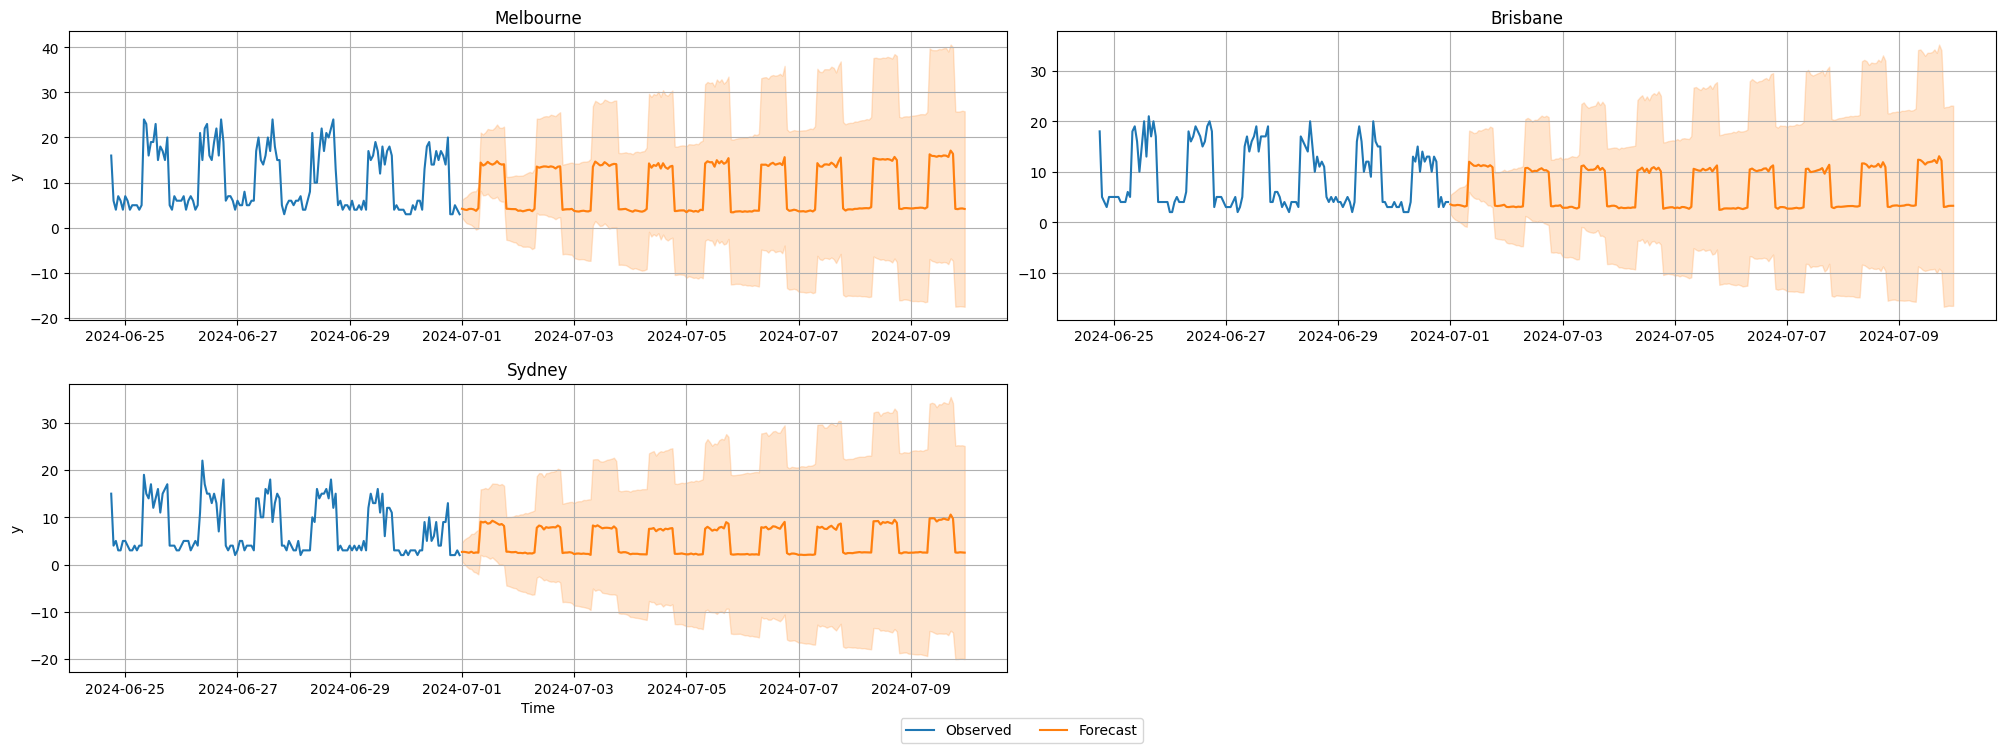

In [20]:
# Plot the actual time series along with the model predictions
predictor.plot(timeseries_df, predictions, max_history_length = 150);

We have a simple model trained on the data. Its performance metrics give us a quick baseline.

# AutoGluon with Covariates

We load future covariates, convert them into the correct format, and retrain the model by including extra features like event days and day of week.


In [21]:
# Load future covariates to enrich the forecasting process
future_covariates = pd.read_csv("australia_library_future.csv")
future_covariates.head()

,datetime,location_name,day_of_week,event_day
0,2024-07-01 00:00:00,Sydney,0,0
1,2024-07-01 01:00:00,Sydney,0,0
2,2024-07-01 02:00:00,Sydney,0,0
3,2024-07-01 03:00:00,Sydney,0,0
4,2024-07-01 04:00:00,Sydney,0,0


In [22]:
# Convert the future covariates DataFrame into a TimeSeriesDataFrame
future_timeseries_df = TimeSeriesDataFrame.from_data_frame(
    future_covariates,
    id_column = 'location_name',
    timestamp_column = "datetime"
    )

In [23]:
# Initialize the TimeSeriesPredictor with known covariates
predictor2 = TimeSeriesPredictor(
    prediction_length = prediction_length,
    target = 'y',
    eval_metric = 'RMSE',
    freq = "h",
    known_covariates_names = ['event_day', 'day_of_week']
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260722_091432"


In [24]:
# Train the model using the covariates
predictor2.fit(
    timeseries_df,
    presets = "best_quality",
    val_step_size = 96,
    random_seed = 1502,
    num_val_windows = 50,
    time_limit = 600
)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/content/drive/MyDrive/Python - Time Series Forecasting/Advanced Content for Time Series/Amazon AutoGluon/AutogluonModels/ag-20260722_091432'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 13.82/14.56 GB
Total GPU Memory:   Free: 13.82 GB, Allocated: 0.74 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.40 GB / 12.67 GB (74.2%)
Disk Space Avail:   54.97 GB / 112.64 GB (48.8%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'h',
 'hyperparameters': 'default',
 'known_covariates_names': ['event_day', 'day_of_week'],
 'num_val_windows': 50,
 'prediction_length

In [25]:
# Display the leaderboard for the new model
predictor2.leaderboard(silent = True)

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-3.055986,0.176570,1.726192,11
1,Chronos2,-3.528473,0.085352,1.615887,5
2,Chronos2SmallFineTuned,-3.569817,0.051798,95.876649,6
3,DynamicOptimizedTheta,-3.629638,0.199266,0.320499,4
4,ChronosWithRegressor[bolt_small],-3.688677,0.710115,1.204839,8
5,DeepAR,-3.933092,1.593458,75.164266,10
6,SeasonalNaive,-4.155233,0.019040,0.074185,1
7,DirectTabular,-4.305612,0.089666,1.823286,3
8,RecursiveTabular,-4.522752,0.990452,5.096569,2
9,TemporalFusionTransformer,-5.887810,0.055763,155.055274,9


In [26]:
# Check the future timeseries data
future_timeseries_df

day_of_week  event_day
item_id  timestamp                                  
Sydney   2024-07-01 00:00:00            0          0
         2024-07-01 01:00:00            0          0
         2024-07-01 02:00:00            0          0
         2024-07-01 03:00:00            0          0
         2024-07-01 04:00:00            0          0
...                                   ...        ...
Brisbane 2024-07-09 19:00:00            1          1
         2024-07-09 20:00:00            1          1
         2024-07-09 21:00:00            1          1
         2024-07-09 22:00:00            1          1
         2024-07-09 23:00:00            1          1

[648 rows x 2 columns]

In [27]:
# Generate predictions using known covariates
predictions2 = predictor2.predict(
    timeseries_df,
    random_seed = 1502,
    known_covariates = future_timeseries_df)
predictions2.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
Sydney  2024-07-01 00:00:00  2.638007  0.818792  1.437220  1.881638  2.270811   
        2024-07-01 01:00:00  2.694433  0.304668  1.112514  1.700756  2.215387   
        2024-07-01 02:00:00  2.608780 -0.213816  0.737850  1.440145  2.044075   
        2024-07-01 03:00:00  2.521312 -0.598382  0.466803  1.241117  1.904377   
        2024-07-01 04:00:00  2.703807 -0.715210  0.461550  1.308824  2.028449   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
Sydney  2024-07-01 00:00:00  2.638007  2.991258  3.385703  3.833742  4.482014  
        2024-07-01 01:00:00  2.694433  3.162934  3.660772  4.252877  5.105661  
        2024-07-01 02:00:00  2.608780  3.156480  3.730062  4.418599  5.405130  
        2024-07-01 03:00:00  2.521312  3.136366  3.799508  4.583146  5.681032  
        2024-07-01 04:00:00  2.703807  3.384044  4.117236  4.982580  6.202474

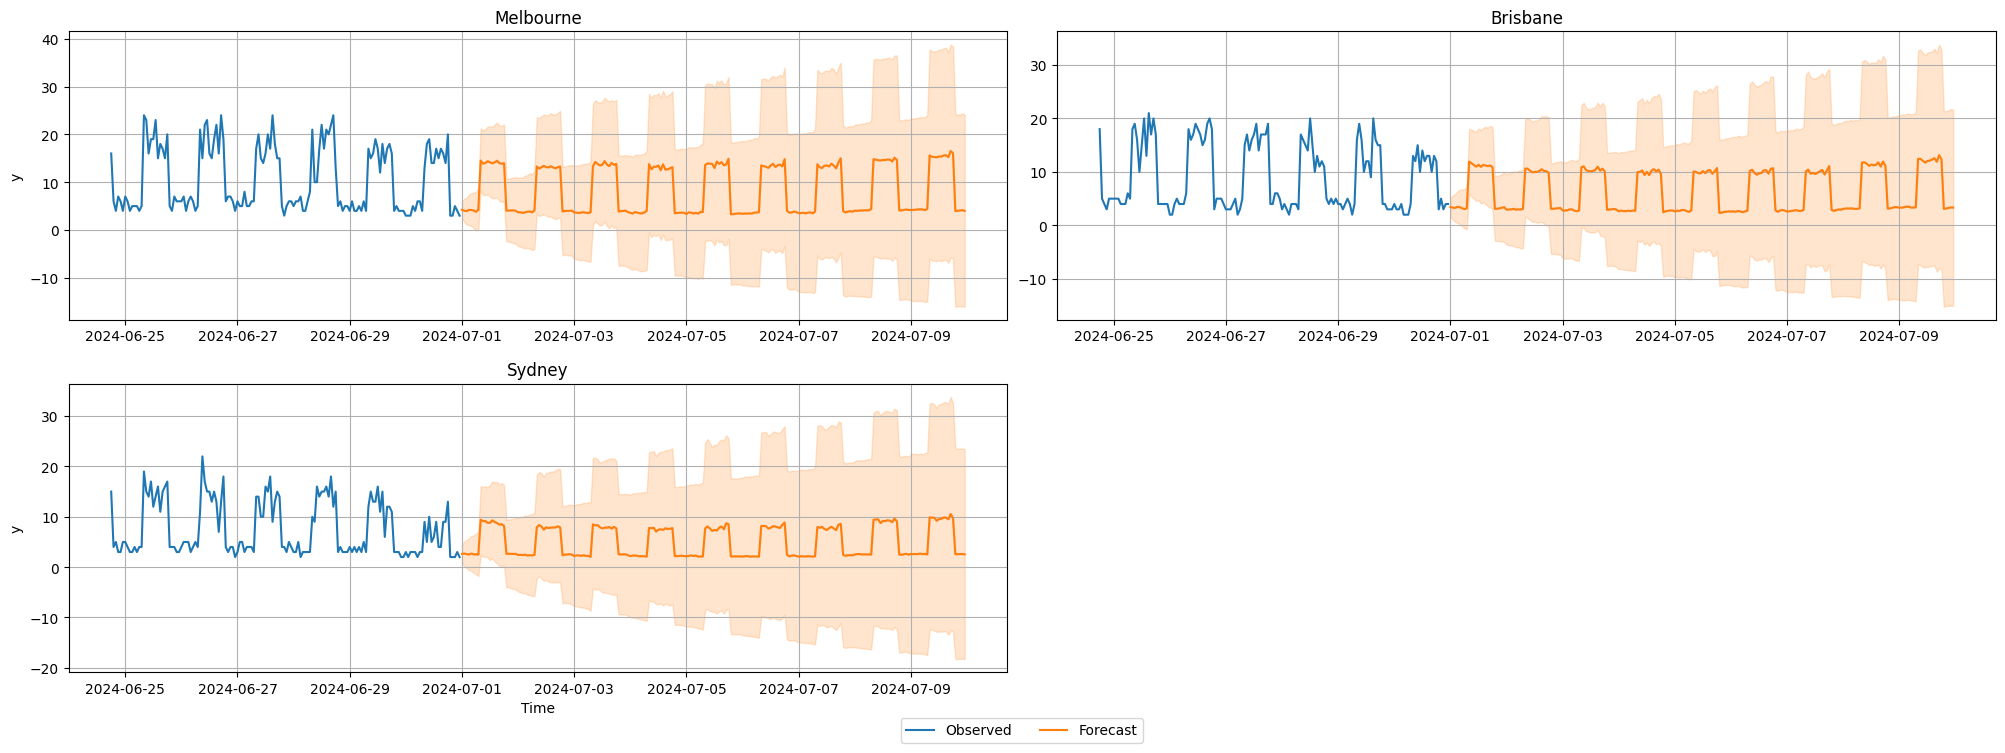

In [28]:
# Plot the actual time series and predictions
predictor2.plot(timeseries_df, predictions2, max_history_length = 150);

We have now included extra features to boost the model's understanding of the data and refine the forecasts.

# Interpretability

We generate and visualize the feature importance to see which features have the biggest impact on the model's predictions.

In [29]:
# Extract and store the feature importance metrics
feature_importance = predictor2.feature_importance(
    timeseries_df
)

Computing feature importance


In [30]:
# Display the feature importance DataFrame
feature_importance

,importance,stdev,n,p99_low,p99_high
temperature,0.044677,0.0,5.0,0.044677,0.044677
day_of_week,0.041069,0.0,5.0,0.041069,0.041069
rainfall,0.035873,0.0,5.0,0.035873,0.035873
event_day,0.005767,0.0,5.0,0.005767,0.005767


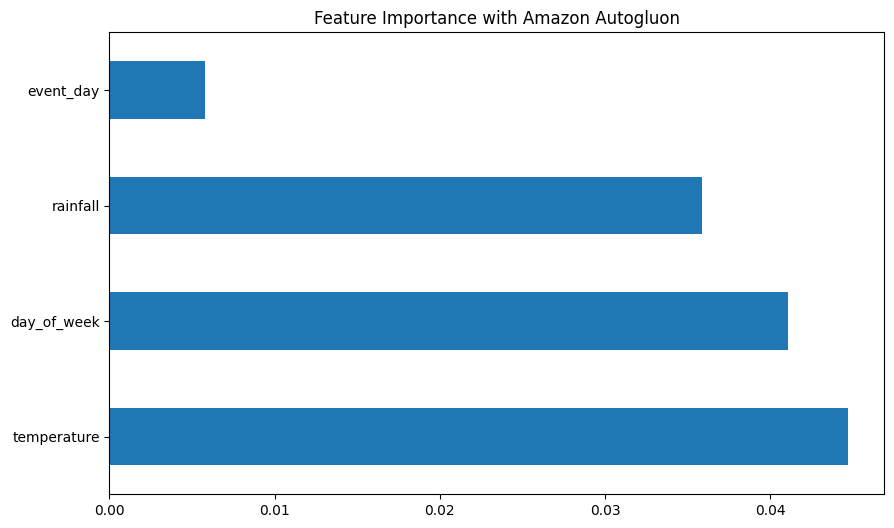

In [31]:
# Plot the feature importance for a clear picture
feature_importance.importance.plot(kind = 'barh', figsize = (10, 6))
plt.title("Feature Importance with Amazon Autogluon")
plt.show();

# Conclusion
We successfully set up an AutoGluon time-series forecasting pipeline, used both basic and covariate-enhanced models, and interpreted the results with feature importance. You can now build on this workflow to make data-driven decisions about library visitor trends in different Australian cities.



In [32]:
!pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
adagio==0.2.6
affine==2.4.0
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.1
aiohttp-cors==0.8.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
alembic==1.18.5
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.14.2
anywidget==0.9.21
apsw==3.53.3.1
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.7.13.0.54.2
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autogluon==1.5.0
autogluon.common==1.5.0
autogluon.core==1.5.0
autogluon.features==1.5.0
autogluon.multimodal==1.5.0
autogluon.tabular==1.5.0
autogluon.timeseries==1.5.0
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinke